# Malware/Botnet Propagation in Heterogeneous IoT Networks

## Research Question

Under what network topologies and infection rates does decentralized local node isolation outperform centralized patching strategies in containing a fast-spreading worm?

## Model Overview

This notebook develops a network-based model of malware propagation in IoT networks.

The model investigates how malware propagation is affected by:

- Network topology
- Infection rate
- Centralized patching
- Decentralized local node isolation

The model is developed incrementally. It begins with the underlying network structure and a baseline malware propagation model before containment strategies are introduced.


# 0. Imports and Global Parameters


In [1]:
import sys
import networkx as nx
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.states import (
    SUSCEPTIBLE,
    INFECTED,
    PATCHED,
    ISOLATED
)

from src.networks import (
    create_random_network,
    create_small_world_network,
    create_scale_free_network
)

from src.propagation import run_simulation

from src.containment import (
    random_patching,
    targeted_patching,
    run_patching_simulation,
    run_isolation_simulation
)

from utils.metrics import (
    count_state,
    average_degree
)

from utils.visualisation import (
    plot_network,
    plot_degree_distribution,
    animate_propagation
)

In [2]:
# Reproducibility
seed = 42

# Full network parameters used for analysis and simulation
n = 1000
target_avg_degree = 6

# Smaller network used only for visualisation
n_vis = 50

# Topology parameters
p_er = target_avg_degree / (n - 1)
k_ws = target_avg_degree
p_rewire = 0.1
m_ba = target_avg_degree // 2

# Baseline malware parameters
beta = 0.1
steps = 50


# 1. Network Model

Each IoT device is represented by a node, while an edge represents a possible communication path between two devices.

Three network topologies are considered:

1. **Random (Erdős–Rényi)**
2. **Small-World (Watts–Strogatz)**
3. **Scale-Free (Barabási–Albert)**

To make comparisons more meaningful, all full simulation networks contain the same number of nodes and have approximately the same average degree:

\[
n = 1000, \qquad \langle k \rangle \approx 6
\]

This reduces the effect of overall network density when comparing topology-dependent behaviour.


## 1.1 Network Generation


In [3]:
random_network = create_random_network(
    n=n,
    p=p_er,
    seed=seed
)

small_world_network = create_small_world_network(
    n=n,
    k=k_ws,
    rewiring_prob=p_rewire,
    seed=seed
)

scale_free_network = create_scale_free_network(
    n=n,
    m=m_ba,
    seed=seed
)

networks = {
    "Random": random_network,
    "Small-World": small_world_network,
    "Scale-Free": scale_free_network
}


## 1.2 Network Visualisation

For visual clarity, smaller networks with 50 nodes are used in topology diagrams. The full 1000-node networks above are used for network analysis and simulation experiments.


In [4]:
# Create smaller networks for visualisation only
p_er_vis = target_avg_degree / (n_vis - 1)

random_vis = create_random_network(
    n=n_vis,
    p=p_er_vis,
    seed=seed
)

small_world_vis = create_small_world_network(
    n=n_vis,
    k=k_ws,
    rewiring_prob=p_rewire,
    seed=seed
)

scale_free_vis = create_scale_free_network(
    n=n_vis,
    m=m_ba,
    seed=seed
)

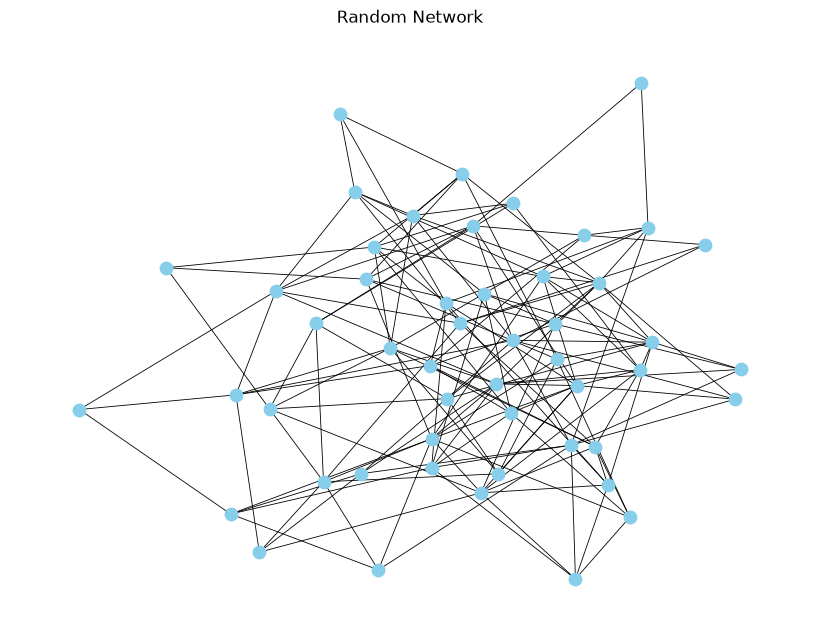

In [5]:
plot_network(random_vis, "Random Network")

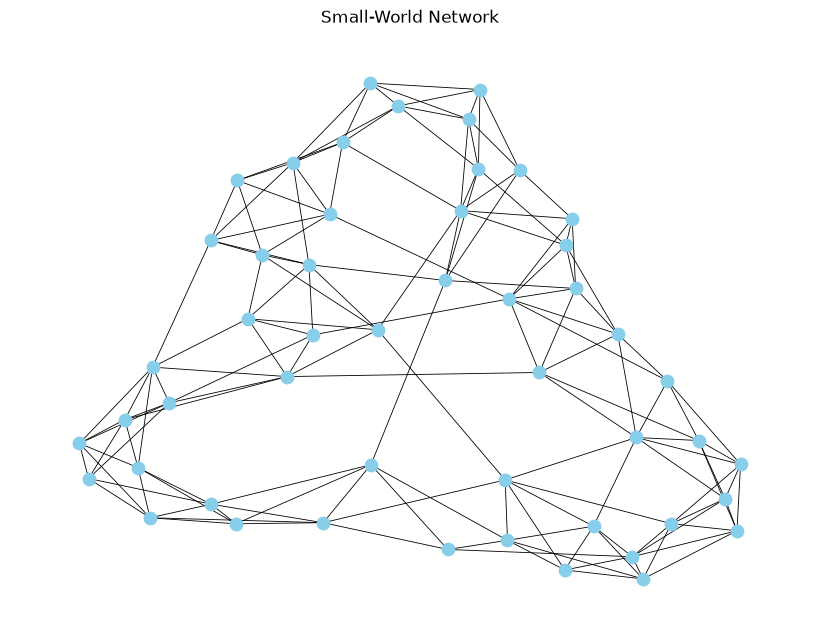

In [6]:
plot_network(small_world_vis, "Small-World Network")

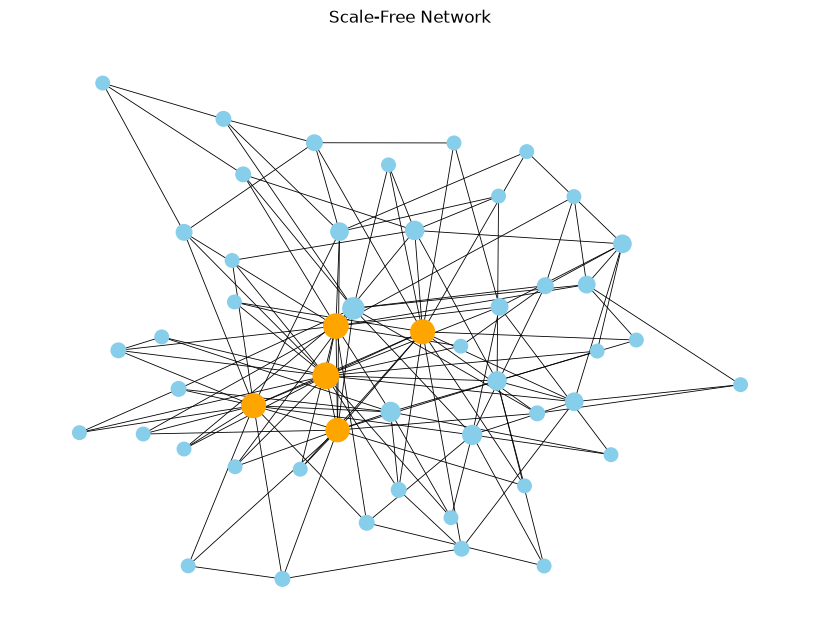

In [7]:
plot_network(scale_free_vis, "Scale-Free Network", highlight_hubs=True)

In the scale-free visualisation, high-degree nodes (top 10% by degree) are highlighted to make hub structure easier to identify. This hub threshold is used only for visualisation at this stage.


## 1.3 Degree Distribution

The degree distribution describes how node degrees are distributed across a network. This is relevant to malware propagation because highly connected devices may provide more opportunities for malware transmission.


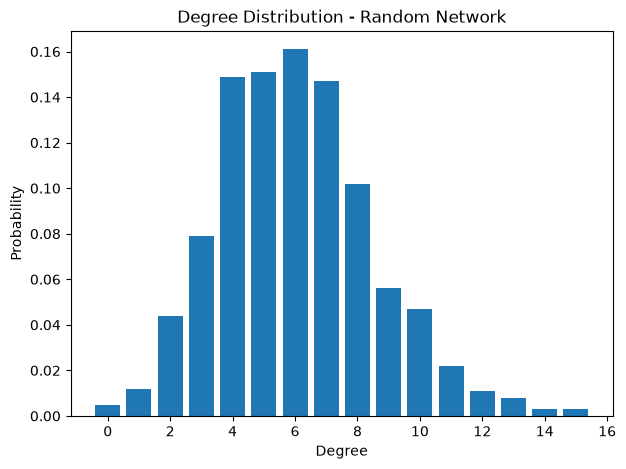

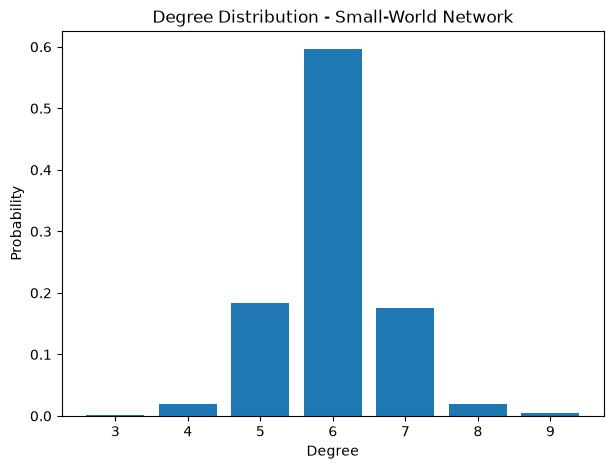

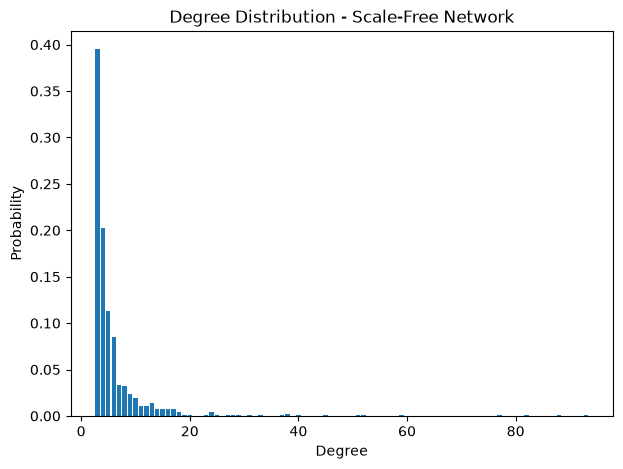

In [8]:
for name, G in networks.items():
    plot_degree_distribution(
        G,
        f"Degree Distribution - {name} Network"
    )


## 1.4 Network Statistics


In [9]:
for name, G in networks.items():
    print(f"{name} Network")
    print(f"  Nodes: {G.number_of_nodes()}")
    print(f"  Edges: {G.number_of_edges()}")
    print(f"  Average degree: {average_degree(G):.3f}")
    print(f"  Connected: {nx.is_connected(G)}")
    print(f"  Average clustering: {nx.average_clustering(G):.3f}")
    print()


Random Network
  Nodes: 1000
  Edges: 3019
  Average degree: 6.038
  Connected: False
  Average clustering: 0.009

Small-World Network
  Nodes: 1000
  Edges: 3000
  Average degree: 6.000
  Connected: True
  Average clustering: 0.452

Scale-Free Network
  Nodes: 1000
  Edges: 2991
  Average degree: 5.982
  Connected: True
  Average clustering: 0.033



# 2. Malware Propagation Model

The baseline model initially uses two node states:

- **Susceptible (S):** the device is vulnerable but not infected.
- **Infected (I):** the device is infected and can attempt to infect neighbouring devices.

The simulation begins with one randomly selected infected node.

At each simulation step, every infected node independently attempts to infect each susceptible neighbour with probability \(\beta\). State updates are synchronous: newly infected nodes become active only after the current step has finished.

The baseline model therefore behaves as an SI-style process: once a device becomes infected, it remains infected until containment mechanisms are introduced later.


## 2.1 Node States and Initial Infection

The baseline propagation model uses two node states:

- **Susceptible (S):** the device is vulnerable but has not been infected.
- **Infected (I):** the device is infected and can transmit malware to neighbouring susceptible devices.

At the beginning of each baseline simulation, all nodes are reset to the susceptible state and one node is selected randomly as the initial infected device.

The node-state definitions and initialisation logic are implemented in `src/states.py` and `src/propagation.py`.

## 2.2 Infection Rule

At each simulation step, every infected device attempts to transmit malware independently to each susceptible neighbour with probability $\beta$.

New infections are stored temporarily and applied only after all infection attempts for the current step have been evaluated. This synchronous update prevents a newly infected node from transmitting malware again during the same simulation step.

The infection rule is implemented by `infection_step()` in `src/propagation.py`.

## 2.3 Simulation

The simulation repeatedly applies the infection rule for a fixed number of steps.

For each step, the model records:

- the total number of infected devices; and
- the state of every node for later visualisation.

The simulation logic is implemented by `run_simulation()` in `src/propagation.py`.

## 2.4 Propagation Animation

A smaller network is used for animation so that individual node-state changes remain visible. Blue nodes are susceptible and red nodes are infected.


# 3. Baseline Experiments

The same baseline infection probability and number of simulation steps are applied to each topology. At this stage, these runs are intended primarily as model validation and preliminary exploration.

A single stochastic run is not sufficient for final conclusions. Formal experiments should later repeat simulations across multiple random seeds and infection rates.


## 3.1 Run Baseline Simulation Across All Topologies


In [10]:
results = {}

for name, G in networks.items():
    infected_history, states_history = run_simulation(
        G,
        beta=beta,
        steps=steps,
        seed=seed
    )

    results[name] = {
        "infected": infected_history,
        "states": states_history
    }


## 3.2 Compare Infection Curves


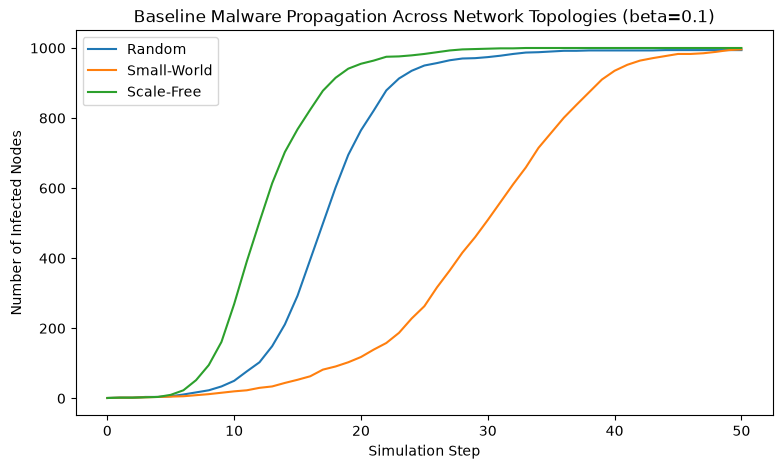

In [11]:
plt.figure(figsize=(9, 5))

for name, result in results.items():
    plt.plot(
        result["infected"],
        label=name
    )

plt.xlabel("Simulation Step")
plt.ylabel("Number of Infected Nodes")
plt.title(
    f"Baseline Malware Propagation Across Network Topologies "
    f"(beta={beta})"
)
plt.legend()
plt.show()


### Preliminary Observation

The scale-free network shows particularly rapid malware propagation. A possible explanation is its heterogeneous degree distribution: most nodes have relatively few connections, while a small number of hub nodes have very high degree.

If the malware reaches one of these hubs, the infected hub can expose many susceptible neighbours within a single simulation step, potentially accelerating propagation across the network.

In contrast, the small-world network has a more homogeneous degree distribution but relatively high clustering. Infection can therefore spread efficiently within local clusters, while rewired long-range connections provide paths for the malware to reach other parts of the network.

These results are preliminary because each curve currently represents only a single stochastic simulation. Multiple runs across different random seeds and infection rates are required before drawing conclusions about the effect of network topology.|

## 3.3 Animation Examples

The cells below generate small demonstration networks using approximately the same target average degree. Change `demo_name` to `"Random"`, `"Small-World"`, or `"Scale-Free"` to visualise a different topology.


In [12]:
demo_networks = {
    "Random": create_random_network(
        n=n_vis,
        p=target_avg_degree / (n_vis - 1),
        seed=seed
    ),

    "Small-World": create_small_world_network(
        n=n_vis,
        k=target_avg_degree,
        rewiring_prob=p_rewire,
        seed=seed
    ),

    "Scale-Free": create_scale_free_network(
        n=n_vis,
        m=target_avg_degree // 2,
        seed=seed
    )
}


for demo_name, demo_network in demo_networks.items():

    demo_history, demo_states = run_simulation(
        demo_network,
        beta=beta,
        steps=20,
        seed=seed
    )

    animation = animate_propagation(
        demo_network,
        demo_states,
        demo_history,
        title=f"{demo_name} Network"
    )

    display(animation)

# 4. Containment Strategies

Three containment strategies are introduced to reduce malware propagation:

1. **Random Centralized Patching**
2. **Degree-Targeted Centralized Patching**
3. **Decentralized Local Isolation**

The two centralized strategies apply preventive patches before malware propagation begins. Random patching allocates a fixed patching budget without considering network topology, while degree-targeted patching prioritises highly connected nodes.

The decentralized strategy operates dynamically during malware propagation. Individual susceptible devices respond to infection detected in their local neighbourhood and may isolate themselves from the network.

## 4.1 Containment States and Strategy Overview

The baseline malware model contains two node states: **Susceptible (S)** and **Infected (I)**. To model containment, two additional states are introduced:

- **Patched (P):** The device has received a preventive security patch before malware propagation begins and is protected from future infection. Patched devices remain in state $P$ and do not participate in malware transmission. Infected devices cannot transition to the patched state.
- **Isolated (X):** The device has disconnected itself from network communication in response to a locally detected infection risk. An isolated device cannot be infected and does not participate in malware transmission.

The model compares three containment strategies:

### Strategy 1 — Random Centralized Patching

A centralized controller has a fixed preventive patching budget and randomly selects devices to patch before malware propagation begins.

The strategy does not use information about network topology, so every susceptible device has an equal probability of being selected. This provides a baseline for evaluating whether more informed patch allocation can improve containment.

### Strategy 2 — Degree-Targeted Centralized Patching

The centralized controller uses global information about the network topology and prioritises devices with higher degree.

High-degree nodes have more connections and may provide more potential transmission paths. This is particularly relevant in scale-free networks, where a small number of highly connected hub nodes can play an important role in malware propagation.

This strategy allows us to investigate whether using network topology information improves the effectiveness of centralized patching.

### Strategy 3 — Decentralized Local Isolation

Unlike centralized patching, local isolation does not require global knowledge of the network.

Each susceptible device monitors its immediate neighbours. If at least one neighbouring device is infected, the device detects a local infection risk and may isolate itself with probability $\alpha$.

This strategy therefore relies only on local information and allows devices to respond independently to nearby malware activity.

## 4.2 Random Centralized Patching

The random centralized patching strategy represents a preventive intervention deployed before malware propagation begins.

A central controller has a fixed patching budget $B$, representing the maximum proportion of devices that can be patched. Under random patching, devices are selected randomly without considering their position or importance in the network.

Only susceptible devices can be patched:

- $S \rightarrow P$: the device is protected from future malware infection.
- $I \nrightarrow P$: patching does not remove an existing malware infection.

Patched devices remain in state $P$ for the remainder of the simulation and cannot become infected or participate in malware transmission.

The patching budget is applied once before the malware begins to spread. This prevents the controller from eventually patching the entire network simply by running the simulation for more steps.

This strategy provides a baseline for evaluating whether using network topology information can improve patch allocation.

### 4.2.1 Patching Parameters

The patching budget $B$ represents the maximum proportion of devices that can receive a preventive security patch before malware propagation begins.

For the preliminary experiment, the patching budget is set to 20%. The same budget will later be used for both random and degree-targeted patching to ensure a fair comparison between the two allocation strategies.

In [13]:
patch_budget = 0.2

### 4.2.2 Random Patch Allocation

The random patching function first identifies all susceptible devices that are eligible to receive a patch.

The number of devices selected is determined by the fixed patching budget $B$. Devices are then selected uniformly at random without replacement, meaning that each eligible device has an equal chance of being patched and no device can be selected more than once.

Selected devices transition from susceptible to patched:

$S \rightarrow P$

Because this strategy does not consider node degree or other topological properties, it provides a topology-independent baseline for comparison with degree-targeted patching.

### 4.2.3 Patching Initialisation

The baseline simulation introduced in Section 2 begins by randomly infecting one susceptible device. For simulations involving preventive patching, the initialisation process is extended so that patch deployment occurs before the malware is introduced.

At the beginning of each simulation:

1. All devices are reset to the susceptible state.
2. The selected patching strategy is applied according to the fixed patching budget.
3. One device is randomly selected from the remaining susceptible devices as the initial infected node.

This ordering ensures that patching represents preventive protection rather than treatment of an existing infection.

The initialisation function accepts the patching strategy as an argument, allowing the same procedure to be reused later for both random and degree-targeted patching.

### 4.2.4 Preliminary Simulation

To verify the behaviour of the preventive random patching strategy, the model is applied to each network topology using the same infection probability and patching budget.

These simulations provide an initial comparison with the no-containment baseline. Formal evaluation using repeated simulations and multiple parameter values will be conducted in the later experimental section.

In [14]:
random_patch_results = {}

for name, G in networks.items():
    random_patch_results[name] = run_patching_simulation(
        G,
        beta=beta,
        steps=steps,
        patch_strategy=random_patching,
        patch_budget=patch_budget,
        seed=seed
    )

### 4.2.5 Preliminary Results

The preliminary results are used to examine whether random preventive patching changes malware propagation across the three network topologies.

First, the infection curves under random patching are compared across the Random, Small-World, and Scale-Free networks. The patched networks use the same infection probability $\beta$ and the same patching budget $B$.

The results are then compared with the corresponding no-containment baseline to provide an initial indication of the effect of preventive random patching.

These results are based on a single stochastic simulation for each topology and therefore should not be interpreted as final evidence of strategy effectiveness.


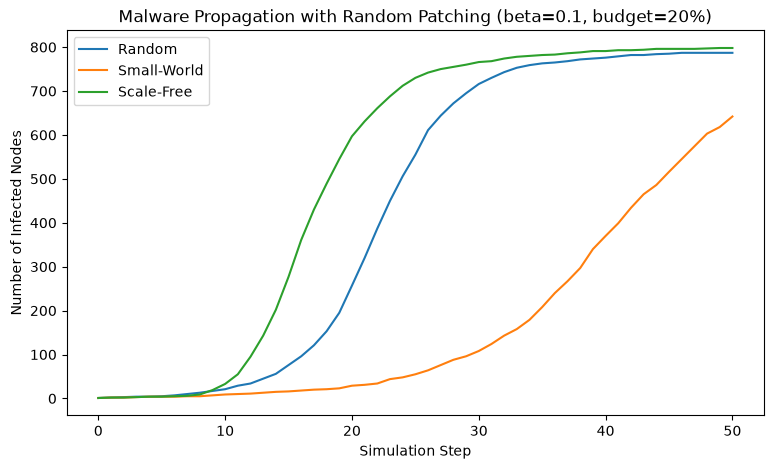

In [15]:
plt.figure(figsize=(9, 5))

for name, history in random_patch_results.items():
    plt.plot(
        history,
        label=name
    )

plt.xlabel("Simulation Step")
plt.ylabel("Number of Infected Nodes")

plt.title(
    f"Malware Propagation with Random Patching "
    f"(beta={beta}, budget={patch_budget:.0%})"
)

plt.legend()
plt.show()

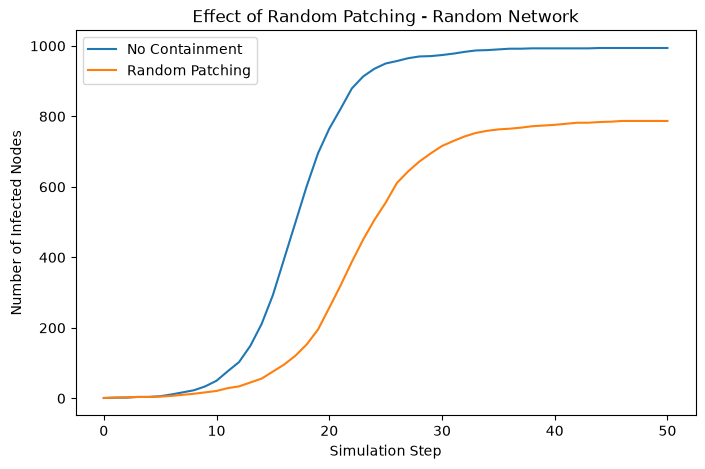

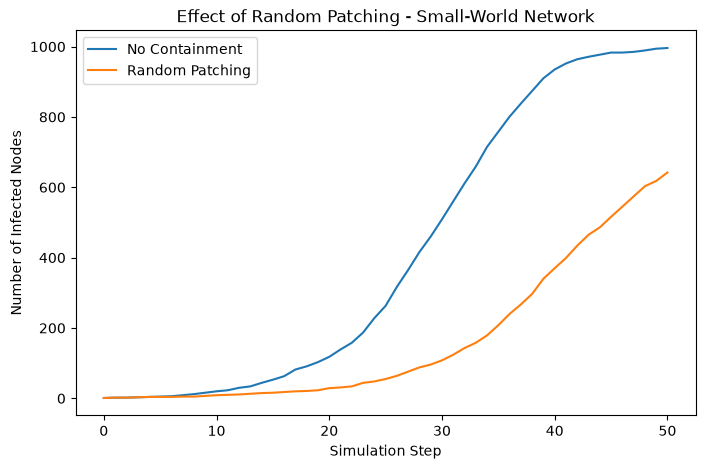

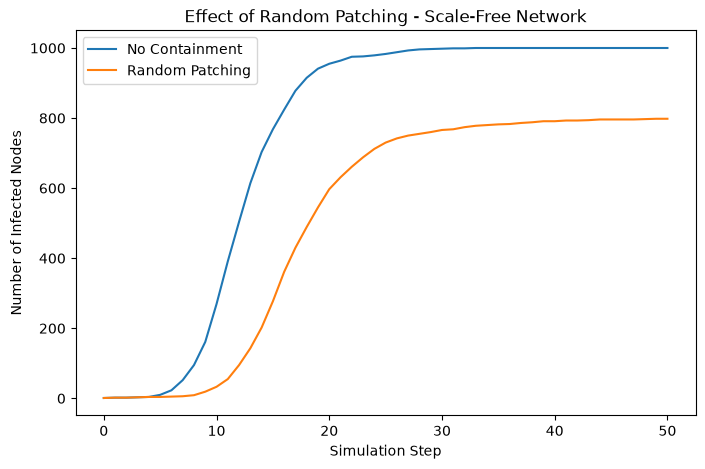

In [16]:
for name in networks.keys():

    plt.figure(figsize=(8, 5))

    plt.plot(
        results[name]["infected"],
        label="No Containment"
    )

    plt.plot(
        random_patch_results[name],
        label="Random Patching"
    )

    plt.xlabel("Simulation Step")
    plt.ylabel("Number of Infected Nodes")

    plt.title(
        f"Effect of Random Patching - {name} Network"
    )

    plt.legend()
    plt.show()

In [17]:
print("Final state summary:")

for name, G in networks.items():
    state_counts = {
        state: count_state(G, state)
        for state in [SUSCEPTIBLE, INFECTED, PATCHED]
    }

    total = G.number_of_nodes()

    print(
        f"{name}: "
        f"S={state_counts[SUSCEPTIBLE]} "
        f"({state_counts[SUSCEPTIBLE] / total:.1%}), "
        f"I={state_counts[INFECTED]} "
        f"({state_counts[INFECTED] / total:.1%}), "
        f"P={state_counts[PATCHED]} "
        f"({state_counts[PATCHED] / total:.1%})"
    )

Final state summary:
Random: S=13 (1.3%), I=787 (78.7%), P=200 (20.0%)
Small-World: S=158 (15.8%), I=642 (64.2%), P=200 (20.0%)
Scale-Free: S=2 (0.2%), I=798 (79.8%), P=200 (20.0%)


### Preliminary Observation

With the same 20% random patching budget, the three network topologies show noticeably different propagation behaviour.

The **Scale-Free network** shows the highest final infection level, with almost all unpatched devices eventually becoming infected. A possible explanation is its heterogeneous degree distribution and the presence of highly connected hub nodes. Because patches are allocated randomly, important hubs are not specifically protected. If the malware reaches an unpatched hub, it can still access many neighbouring devices and rapidly propagate through the remaining network. Therefore, random patching may provide relatively limited structural disruption in a scale-free network.

The **Random network** also shows a high final infection level. Unlike the scale-free network, its connections are distributed more uniformly and there are fewer structurally dominant nodes whose protection would strongly disrupt propagation. Randomly removing 20% of susceptible devices therefore reduces the number of available hosts, but many alternative transmission paths may remain between the unpatched devices.

The **Small-World network** retains substantially more susceptible devices in this preliminary run. One possible explanation is its relatively high local clustering: random patching may disrupt some local transmission paths and make it more difficult for the infection to move between parts of the network. However, this behaviour may depend strongly on which nodes are patched and where the initial infection occurs.

These observations are based on a single stochastic simulation and should therefore be treated as preliminary. Repeated simulations across different random seeds and parameter values are required to determine whether these differences are consistent.

## 4.3 Degree-Targeted Centralized Patching

Random patching treats all susceptible devices equally and does not consider their structural importance within the network. However, nodes with higher degree have more connections and may provide more potential paths for malware transmission.

Degree-targeted patching extends the centralized strategy by using global knowledge of the network topology. Before malware propagation begins, susceptible nodes are ranked according to their degree, and the nodes with the highest degree are patched first until the fixed patching budget $B$ is exhausted.

The state transition remains the same as in random patching:

- $S \rightarrow P$: a susceptible device is protected from future infection.
- $I \nrightarrow P$: patching is preventive and does not remove an existing infection.

The same patching budget is used for both random and degree-targeted patching. Therefore, the main difference between the two strategies is how the available patches are allocated.

This strategy is expected to be particularly relevant to scale-free networks, where a small number of highly connected hub nodes may provide important transmission paths. Prioritising these nodes may therefore reduce malware propagation more effectively than allocating the same number of patches randomly. This expectation will be evaluated through simulation rather than assumed.

### 4.3.1 Targeted Patch Allocation

Eligible susceptible nodes are ranked in descending order of degree. The highest-degree nodes are selected first until the patching budget is reached.

This differs from random patching only in the node-selection mechanism, allowing the effect of topology-aware patch allocation to be compared while keeping the intervention budget unchanged.

### 4.3.2 Preliminary Simulation

The degree-targeted patching strategy is evaluated using the same simulation framework, infection probability, patching budget, and number of simulation steps as random patching.

The only difference is the patch allocation strategy: instead of selecting susceptible nodes randomly, the highest-degree susceptible nodes are patched first.

Keeping the remaining parameters unchanged allows the preliminary results to isolate the effect of topology-aware patch allocation.

In [18]:
targeted_patch_results = {}

for name, G in networks.items():
    targeted_patch_results[name] = run_patching_simulation(
        G,
        beta=beta,
        steps=steps,
        patch_strategy=targeted_patching,
        patch_budget=patch_budget,
        seed=seed
    )

### 4.3.3 Preliminary Results

The preliminary results compare malware propagation across the three network topologies after applying degree-targeted preventive patching.

All networks use the same infection probability $\beta$, patching budget $B$, and simulation duration as the previous random patching experiment. Therefore, differences between the random and targeted patching results arise from how the available patches are allocated rather than from differences in intervention resources.

The first comparison examines how malware propagates across the Random, Small-World, and Scale-Free networks under degree-targeted patching. The results are then compared with both the no-containment baseline and random patching to evaluate whether prioritising high-degree nodes provides an additional containment benefit.

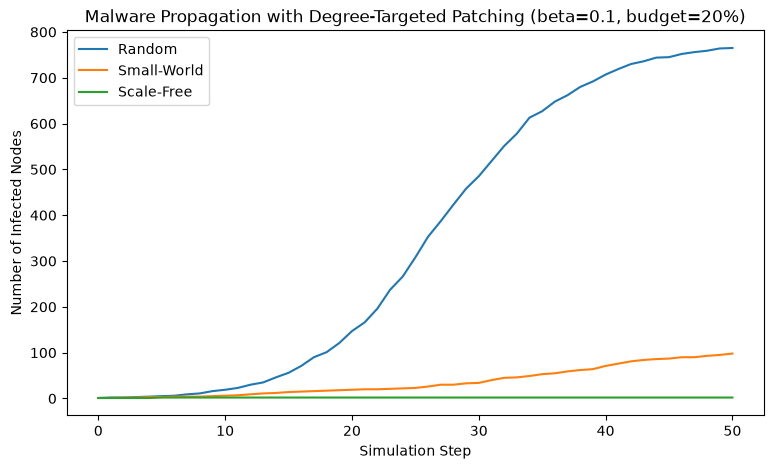

In [19]:
plt.figure(figsize=(9, 5))

for name, history in targeted_patch_results.items():
    plt.plot(
        history,
        label=name
    )

plt.xlabel("Simulation Step")
plt.ylabel("Number of Infected Nodes")

plt.title(
    f"Malware Propagation with Degree-Targeted Patching "
    f"(beta={beta}, budget={patch_budget:.0%})"
)

plt.legend()
plt.show()

In [20]:
print("Final state summary:")

for name, G in networks.items():
    state_counts = {
        state: count_state(G, state)
        for state in [SUSCEPTIBLE, INFECTED, PATCHED]
    }

    total = G.number_of_nodes()

    print(
        f"{name}: "
        f"S={state_counts[SUSCEPTIBLE]} "
        f"({state_counts[SUSCEPTIBLE] / total:.1%}), "
        f"I={state_counts[INFECTED]} "
        f"({state_counts[INFECTED] / total:.1%}), "
        f"P={state_counts[PATCHED]} "
        f"({state_counts[PATCHED] / total:.1%})"
    )

Final state summary:
Random: S=35 (3.5%), I=765 (76.5%), P=200 (20.0%)
Small-World: S=702 (70.2%), I=98 (9.8%), P=200 (20.0%)
Scale-Free: S=798 (79.8%), I=2 (0.2%), P=200 (20.0%)


### Preliminary Observation

Degree-targeted patching produces substantially different outcomes across the three network topologies.

The most significant effect is observed in the **Scale-Free network**, where only 2 nodes (0.2%) become infected under degree-targeted patching. This is substantially lower than under random patching, where 798 nodes (79.8%) became infected. This result is consistent with the structural properties of scale-free networks: a relatively small number of high-degree hub nodes provide a large proportion of the network's connectivity. By prioritising these hubs for preventive patching, many important transmission pathways are disrupted before malware propagation begins.

The **Small-World network** also shows a substantial reduction in infection, with 98 nodes (9.8%) becoming infected compared with 642 nodes (64.2%) under random patching. Although the degree distribution is less heterogeneous than in the Scale-Free network, prioritising higher-degree nodes may still disrupt important connections between locally clustered regions and restrict wider propagation.

In contrast, the **Random network** shows a smaller improvement, with the final infected population decreasing from 787 nodes (78.7%) under random patching to 765 nodes (76.5%) under degree-targeted patching. Because node degrees are more homogeneous in the Random network, the highest-degree nodes are less structurally dominant than the hubs found in the Scale-Free network. Therefore, targeting nodes by degree provides less additional benefit over random allocation.

These preliminary results suggest that the effectiveness of topology-aware patching depends strongly on network structure. In particular, degree-targeted patching appears highly effective when network connectivity is concentrated around a small number of important nodes. However, these results are based on a single stochastic simulation and require repeated experiments across different seeds, infection probabilities, and patching budgets before drawing general conclusions.

## 4.4 Decentralized Local Isolation

The third containment strategy considered is decentralized local isolation. Unlike centralized patching, this strategy does not require a central controller or global knowledge of the network topology.

During malware propagation, each susceptible device monitors the infection state of its immediate neighbours. If at least one neighbouring device is infected, the susceptible device is considered exposed to a local infection risk and may isolate itself with probability $\alpha$.

An isolated device transitions from:

$S \rightarrow X$

where $X$ represents the isolated state. Once isolated, the device no longer participates in network communication and therefore cannot become infected or contribute to malware transmission.

The parameter $\alpha$ represents the effectiveness of the local isolation response. A higher value of $\alpha$ means that exposed devices are more likely to isolate themselves before malware reaches them.

Unlike preventive patching, local isolation is reactive and occurs dynamically during the outbreak. It therefore relies only on local neighbourhood information rather than global network topology.

### 4.4.1 Local Isolation Parameter

The local isolation probability $\alpha$ controls the probability that a susceptible device isolates itself after detecting at least one infected neighbour.

For the preliminary simulation, $\alpha$ is set to 0.1. This represents a relatively weak local response in which an exposed susceptible device has a 10% probability of successfully isolating itself during each simulation step.

A relatively low value is used for the preliminary experiment so that both malware propagation and local isolation remain observable. Stronger isolation responses will be investigated later through parameter experiments.

In [21]:
isolation_prob = 0.1

### 4.4.2 Local Isolation Rule

At each simulation step, susceptible devices examine only their immediate neighbours.

If a susceptible device has at least one infected neighbour, it becomes exposed to a local infection risk and may isolate itself with probability $\alpha$:

$S \rightarrow X$

Devices without infected neighbours do not take any isolation action.

The decision is based entirely on local information and does not depend on node degree, global network structure, or the states of distant devices.

Because isolation and malware transmission may affect the same susceptible device during a simulation step, the isolation rule is integrated with the infection process using a synchronous update scheme in the following section.

### 4.4.3 Synchronous Infection and Isolation

Unlike preventive patching, local isolation occurs dynamically during malware propagation. Therefore, infection and isolation decisions must be incorporated into the same simulation step.

A synchronous update scheme is used. All decisions during a simulation step are based on the node states at the beginning of that step, and state changes are applied only after all nodes have been evaluated.

For each susceptible device with at least one infected neighbour:

1. The device first attempts to isolate with probability $\alpha$.
2. If isolation succeeds, the device transitions from $S$ to $X$ and does not become infected during that step.
3. If isolation does not occur, each infected neighbour provides an independent opportunity for malware transmission with probability $\beta$.
4. If at least one transmission attempt succeeds, the device transitions from $S$ to $I$.

This rule represents local isolation as a reactive defence that may prevent an exposed device from becoming infected. All transitions are determined from the same network state, avoiding sequential updates within a simulation step.

### 4.4.4 Preliminary Simulation

The local isolation strategy is evaluated on the same three network topologies used in the baseline and centralized patching experiments.

Unlike the patching strategies, no devices are protected before the outbreak begins. The simulation starts with one infected device, after which infection and local isolation occur dynamically at each simulation step.

For the preliminary experiment, the infection probability is kept at the baseline value and the local isolation probability is set to $\alpha = 0.1$.

In [22]:
isolation_results = {}

for name, G in networks.items():

    infected_history, isolated_history = run_isolation_simulation(
        G,
        beta=beta,
        isolation_prob=isolation_prob,
        steps=steps,
        seed=seed
    )

    isolation_results[name] = {
        "infected": infected_history,
        "isolated": isolated_history
    }

### 4.4.5 Preliminary Results

The preliminary results examine the behaviour of decentralized local isolation across the three network topologies.

Unlike preventive patching, local isolation responds dynamically to nearby infections. Therefore, both the number of infected devices and the number of isolated devices are considered when evaluating the strategy.

A low infection level does not necessarily indicate an efficient containment strategy if a large proportion of the network must be isolated. The results therefore provide an initial view of the trade-off between malware containment and network availability.

As with the previous preliminary experiments, these results are based on a single stochastic simulation and will require repeated experiments before drawing general conclusions.

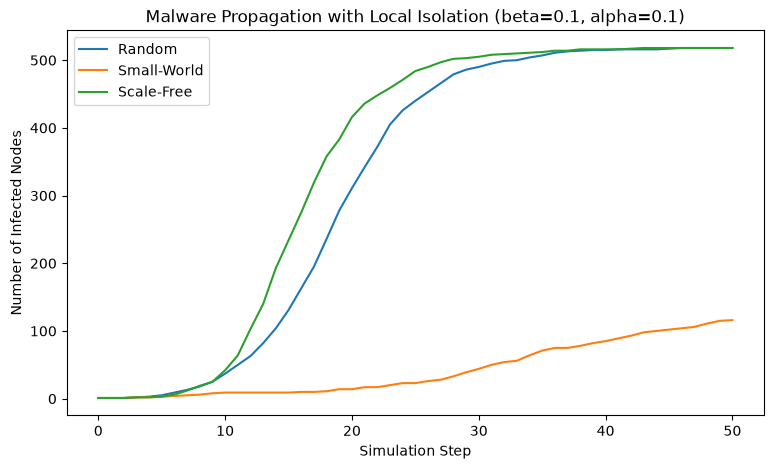

In [23]:
plt.figure(figsize=(9, 5))

for name, result in isolation_results.items():
    plt.plot(
        result["infected"],
        label=name
    )

plt.xlabel("Simulation Step")
plt.ylabel("Number of Infected Nodes")

plt.title(
    f"Malware Propagation with Local Isolation "
    f"(beta={beta}, alpha={isolation_prob})"
)

plt.legend()
plt.show()

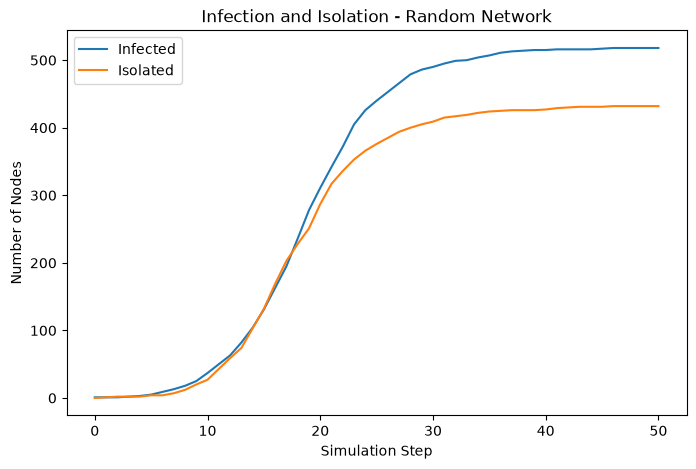

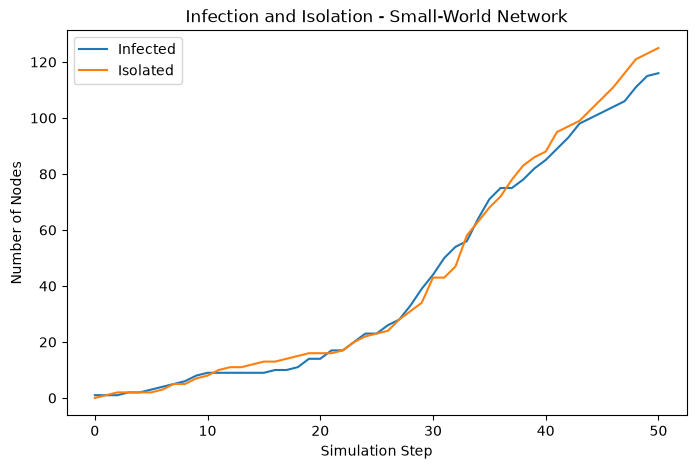

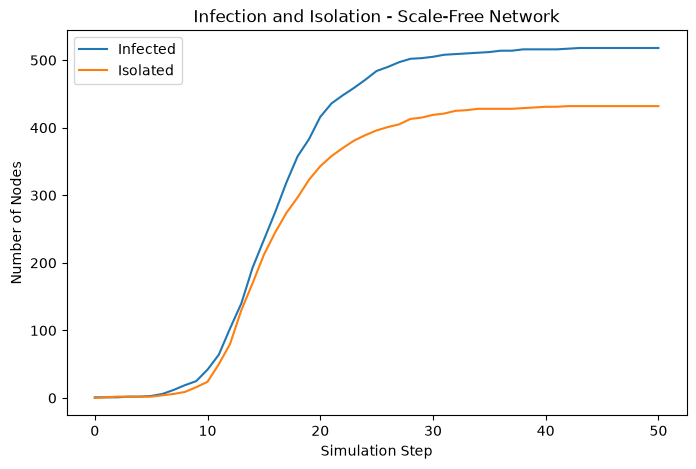

In [24]:
for name, result in isolation_results.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        result["infected"],
        label="Infected"
    )

    plt.plot(
        result["isolated"],
        label="Isolated"
    )

    plt.xlabel("Simulation Step")
    plt.ylabel("Number of Nodes")

    plt.title(
        f"Infection and Isolation - {name} Network"
    )

    plt.legend()
    plt.show()

In [25]:
print("Final state summary:")

for name, G in networks.items():

    susceptible = count_state(G, SUSCEPTIBLE)
    infected = count_state(G, INFECTED)
    isolated = count_state(G, ISOLATED)

    total = G.number_of_nodes()

    print(
        f"{name}: "
        f"S={susceptible} ({susceptible / total:.1%}), "
        f"I={infected} ({infected / total:.1%}), "
        f"X={isolated} ({isolated / total:.1%})"
    )

Final state summary:
Random: S=50 (5.0%), I=518 (51.8%), X=432 (43.2%)
Small-World: S=759 (75.9%), I=116 (11.6%), X=125 (12.5%)
Scale-Free: S=50 (5.0%), I=518 (51.8%), X=432 (43.2%)


### Reproducibility and Randomness

A fixed random seed is used throughout the preliminary simulations to ensure reproducibility and to reduce variation caused by stochastic sampling when comparing different network topologies and containment strategies.

However, results obtained from a single seed may depend on a particular sequence of stochastic events. Therefore, the preliminary simulations should not be interpreted as general statistical evidence. The final experiments should repeat each configuration across multiple random seeds and compare aggregated results, such as the mean infection rate and its variability.

> **Future analysis:** In addition to infection and isolation rates, network connectivity after containment could be evaluated using measures such as the size of the largest connected component (LCC). This would help determine whether a strategy preserves a usable connected network rather than only reducing infections.